# Playing with Sentence Embeddings

> **This notebook continues `bert_embeddings.ipynb`.** There we gave *each word* a
> context-aware vector. Sections here pick up at **9** and ask the next natural question:
> how do we get **one vector for a whole sentence** — so we can compare *sentences* by meaning?

That single-vector-per-sentence is the machinery behind **semantic search** and **RAG**. But
it doesn't come for free: we'll see that plain BERT gives *mediocre* sentence vectors, meet
the model family that fixes them (**SBERT**), and then **reproduce the original SBERT paper**
end to end — training on one task, measuring on another, and watching the numbers climb.

In [1]:
# One-time install (skip if you already have these)
# %pip install transformers torch datasets scipy matplotlib sentence-transformers

## 9. From many word vectors to one sentence vector

In the last notebook, one forward pass gave us **one vector per token**. To describe a
*whole sentence* with a single vector, we **pool** those token vectors into one. The simplest,
most reliable recipe is **mean pooling** — just **average all the token vectors**.

It's the exact same forward pass as before; we just combine *all* the token vectors instead of
plucking one out.

In [2]:
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModel, logging

logging.set_verbosity_error()

# Start with plain, un-fine-tuned DistilBERT (same model as the word notebook)
tok_bert = AutoTokenizer.from_pretrained("distilbert-base-uncased")
bert = AutoModel.from_pretrained("distilbert-base-uncased").eval()
print("loaded distilbert-base-uncased")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

loaded distilbert-base-uncased


In [3]:
def embed_sentence(sentence, tokenizer, model):
    """Turn one sentence into a single vector by averaging its word vectors."""
    enc = tokenizer(sentence, return_tensors="pt")
    with torch.no_grad():
        out = model(**enc)
    token_vectors = out.last_hidden_state[0]   # (num_tokens, dim): one row per token
    return token_vectors.mean(0).numpy()       # average the rows -> one vector


def cosine(u, v):
    return float(u.dot(v) / (np.linalg.norm(u) * np.linalg.norm(v)))


vec = embed_sentence("A man is playing a guitar.", tok_bert, bert)
print("one sentence -> one vector, shape:", vec.shape)

one sentence -> one vector, shape: (768,)


## 10. Does plain BERT give *good* sentence vectors? (not really)

The honest test. Four sentence pairs — two **related** (paraphrases) and two **unrelated**. If
the geometry is any good, related pairs should score clearly higher than unrelated ones.

In [4]:
pairs = [
    ("related",   "A man is playing a guitar.",     "Someone is playing a musical instrument."),
    ("unrelated", "A man is playing a guitar.",     "A dog is running through a field."),
    ("related",   "The stock market crashed today.", "Share prices fell sharply."),
    ("unrelated", "The stock market crashed today.", "She baked a chocolate cake."),
]

def show_pair_scores(tokenizer, model, title):
    print(title)
    rel, unrel = [], []
    for kind, a, b in pairs:
        va = embed_sentence(a, tokenizer, model)
        vb = embed_sentence(b, tokenizer, model)
        s = cosine(va, vb)
        (rel if kind == "related" else unrel).append(s)
        print(f"  [{kind:<9}] {s:.3f}   {a[:30]:<32} | {b}")
    print(f"  --> avg related {np.mean(rel):.3f}   vs   avg unrelated {np.mean(unrel):.3f}"
          f"   (gap {np.mean(rel) - np.mean(unrel):.3f})\n")

show_pair_scores(tok_bert, bert, "PLAIN DistilBERT (mean-pooled):")

PLAIN DistilBERT (mean-pooled):
  [related  ] 0.941   A man is playing a guitar.       | Someone is playing a musical instrument.
  [unrelated] 0.868   A man is playing a guitar.       | A dog is running through a field.
  [related  ] 0.870   The stock market crashed today   | Share prices fell sharply.


  [unrelated] 0.687   The stock market crashed today   | She baked a chocolate cake.
  --> avg related 0.906   vs   avg unrelated 0.778   (gap 0.128)



Look at the scale: **everything scores high**, even the unrelated pairs. Related vs.
unrelated are barely separated — a tiny gap. Plain BERT packs all sentences into a narrow
cone of the space (this is called **anisotropy**), so cosine can't tell meaning apart well.

Why? Think back to what BERT was trained on: **masked language modeling** — predict a missing
*word*. It was **never** asked to make *whole-sentence* vectors comparable. Good sentence
geometry was never part of its objective, so we only get it by accident. To fix that, we need a
model that was trained *for exactly this*.

## 11. The ready-made fix: the `sentence-transformers` library

**Sentence-BERT (SBERT)** is a BERT given a *second* round of training aimed squarely at
sentence similarity. The easiest way to use one is the **`sentence-transformers`** library.

A little background, because we'll lean on it:

- It's by **Nils Reimers & Iryna Gurevych** — the *same* authors as the SBERT paper we
  reproduce in Part II. The library is the reference implementation of that line of work.
- It hosts hundreds of ready-made models on the HuggingFace Hub (we'll use the small, popular
  **`all-MiniLM-L6-v2`**) and wraps everything behind one call: `model.encode(sentence)`.
- That one call is **not magic**. Under the hood it does exactly three steps — **run the
  transformer → mean-pool the token vectors → L2-normalize** — the same mean pool we just
  wrote, plus a normalize on the end.

First, the payoff: load the SBERT model with plain `AutoModel` and our *same* `embed_sentence`,
and re-run the identical test. The **only** thing that changed from Section 10 is the weights.

In [5]:
tok_sbert = AutoTokenizer.from_pretrained("sentence-transformers/all-MiniLM-L6-v2")
sbert = AutoModel.from_pretrained("sentence-transformers/all-MiniLM-L6-v2").eval()

show_pair_scores(tok_sbert, sbert, "SBERT (all-MiniLM-L6-v2, mean-pooled):")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

SBERT (all-MiniLM-L6-v2, mean-pooled):
  [related  ] 0.697   A man is playing a guitar.       | Someone is playing a musical instrument.
  [unrelated] 0.103   A man is playing a guitar.       | A dog is running through a field.
  [related  ] 0.642   The stock market crashed today   | Share prices fell sharply.
  [unrelated] -0.003   The stock market crashed today   | She baked a chocolate cake.
  --> avg related 0.669   vs   avg unrelated 0.050   (gap 0.620)



Now the numbers **spread out**: related pairs stay high, unrelated pairs drop toward 0.
The gap is large and the ordering is trustworthy. Same pooling, same forward pass — the
fine-tuned weights are what made cosine similarity meaningful for sentences.

### Is our mean-pool really what `encode()` does?

We claimed `model.encode()` is just *mean-pool + normalize*. Let's **prove it** — there should
be no hidden magic in the one-liner. We compare three things on the same sentence:

1. **our** `embed_sentence` mean-pool (then L2-normalize, to match the library's convention),
2. the model card's official "without sentence-transformers" recipe (masked mean-pool + normalize),
3. the one-line **`SentenceTransformer.encode()`** itself.

If they line up, the convenience call is exactly the pooling we've used all along.

In [6]:
import torch.nn.functional as F

sent = "A man is playing a guitar."

# (1) OUR mean pool from Section 9, then L2-normalize to match the library's convention
v_ours = embed_sentence(sent, tok_sbert, sbert)
v_ours = v_ours / np.linalg.norm(v_ours)

# (2) the model card's official HuggingFace recipe: masked mean-pool + normalize
def mean_pooling(model_output, attention_mask):
    token_embeddings = model_output[0]
    mask = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    return (token_embeddings * mask).sum(1) / mask.sum(1).clamp(min=1e-9)

enc = tok_sbert([sent], padding=True, truncation=True, return_tensors="pt")
with torch.no_grad():
    out = sbert(**enc)
v_official = F.normalize(mean_pooling(out, enc["attention_mask"]), p=2, dim=1)[0].numpy()

print(f"ours vs official HF recipe            : max|diff| = {np.abs(v_ours - v_official).max():.1e}"
      f"   cosine = {cosine(v_ours, v_official):.6f}")

# (3) the one-line SentenceTransformer.encode()
from sentence_transformers import SentenceTransformer
st = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
v_encode = st.encode(sent)
v_encode = v_encode / np.linalg.norm(v_encode)
print(f"ours vs SentenceTransformer.encode()  : max|diff| = {np.abs(v_ours - v_encode).max():.1e}"
      f"   cosine = {cosine(v_ours, v_encode):.6f}")

ours vs official HF recipe            : max|diff| = 0.0e+00   cosine = 1.000000


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

ours vs SentenceTransformer.encode()  : max|diff| = 1.3e-07   cosine = 1.000000


Identical: the hand-written recipe matches ours to the last bit, and the one-line
`encode()` matches to floating-point precision (cosine `1.000000`). The library isn't doing
anything we aren't — it's the same **mean-pool the token vectors**, with a normalize on the
end. Good to know there's no black box in the convenience call.

So `all-MiniLM-L6-v2` is just a BERT whose **weights** make mean-pooled cosine meaningful. That
raises the real question: *how were those weights made?* For that, we go to the paper.

## 12. Where SBERT comes from — what the paper actually did

**Sentence-BERT** (Reimers & Gurevych, 2019 — [arXiv:1908.10084](https://arxiv.org/abs/1908.10084))
introduced the fine-tuning recipe that turns a plain BERT into a sentence model. Nothing about
the *architecture* changes — it's the same BERT, mean-pooled — only the **weights**, moved by a
short extra round of training with a new objective.

**The training data: NLI datasets.** Natural Language Inference datasets — **SNLI** (~570k
pairs) and **MultiNLI** (~430k pairs), combined into ~942k — consist of **sentence pairs**,
each labelled with their logical relationship:

| premise | hypothesis | label |
|---|---|---|
| A soccer game with multiple males playing. | Some men are playing a sport. | **entailment** |
| A man inspects the uniform of a figure. | The man is sleeping. | **contradiction** |
| An older and younger man smiling. | Two men are smiling at cats on the floor. | **neutral** |

**The objective.** The setup is **siamese**: the *same* BERT encodes both sentences of a pair,
each mean-pooled to a vector — $u$ and $v$ — so the two are directly comparable.

> **What's a *siamese* network?** Two copies of the encoder that **share the exact same
> weights**, run on the two sentences in parallel:

```
sentence A ─►┐  SAME BERT   ┌─► u ─┐
             │   weights    │      ├─ compare (cosine) ─► loss
sentence B ─►┘  (shared)    └─► v ─┘
```

> Because both sentences pass through the *identical* function, $u$ and $v$ land in the **same
> space** — that's the whole point of tying the weights, and the only reason their cosine is
> meaningful. It's really **one** network (our `embed_sentence`, used on both sides); the "twin"
> is just the training-time picture, and the loss updates that single shared set of weights. The
> alternative — a **cross-encoder** that reads both sentences at once and emits one score — is
> often more accurate but yields **no reusable per-sentence vector**, so you couldn't pre-embed a
> corpus for search. The siamese / **bi-encoder** design is what gives every sentence a
> standalone vector you can index once and reuse.

Then, for the 3-way label:

$$o = \mathrm{softmax}\big(W_t\,[\,u;\; v;\; |u-v|\,]\big)$$

- concatenate $u$, $v$, and the elementwise $|u-v|$ → a $3n$-dim vector ($n$ = hidden size),
- a single trainable matrix $W_t$ maps it to the 3 NLI classes,
- ordinary cross-entropy against the label.

That's the whole loss. Crucially, **$W_t$ is scaffolding** — it exists only to create a
gradient that pulls entailment pairs together and pushes contradictions apart. At inference you
**throw it away**: a sentence vector is just "encode, mean-pool," the same `embed_sentence`
we've used since Section 9.

> **Aside — the modern variant.** `all-MiniLM-L6-v2` (Section 11) was actually trained with a
> *newer* loss: a **contrastive / in-batch-negatives** objective (MultipleNegativesRankingLoss,
> a.k.a. InfoNCE) over a billion mined pairs. Same idea — pull true pairs together, push the
> rest apart — different mechanics. We reproduce the **original 2019 classification recipe**
> below, since it's the one the paper reports.

## 13. How you measure success — STS, and the train/eval split that matters

How do we know the fine-tune worked? We test on a *different* task: **Semantic Textual
Similarity (STS)**. STS datasets are thousands of sentence pairs, each with a **human
similarity rating** from 0 (unrelated) to 5 (identical meaning). Scoring is three steps:

1. **encode** each sentence → mean-pool → one vector,
2. **cosine similarity** between the pair's vectors → a predicted score,
3. **Spearman rank correlation** between those predictions and the human ratings.

Two design choices make this a *fair* test — and they're the crux of the whole setup:

- **We train on NLI and evaluate on STS — different datasets, different tasks.** The model
  never sees STS during training. So a high STS score can't be memorization; it means the
  *geometry* became generally meaning-aware. (This "train on A, measure on B" is exactly how
  you check a representation *transfers*.)
- **We score the embeddings, not the classifier.** Cosine-on-vectors is what's measured; the
  throwaway head $W_t$ plays no part. Scoring NLI accuracy instead would test scaffolding
  nobody ships.

Spearman is **rank-based**, so it doesn't matter that cosine lives in $[-1, 1]$ while human
scores live in $[0, 5]$ — only whether they *order the pairs the same way*.

## 14. Our reproduction — plain BERT vs. our own SBERT, on STS

We ran the recipe above ourselves: fine-tuned a full `bert-base-uncased` on SNLI + MultiNLI with
the classification objective, one pass over the ~942k pairs, then measured on the STS benchmarks
— **exactly the paper's setup**. The whole thing is pure PyTorch (no `sentence-transformers`),
in `sbert_repro/train_sbert.py`, and took **~13 minutes on one A100**.

> The cells in this section show the recipe and the **recorded results** from that run. Because
> re-running needs the trained checkpoint (and a GPU), the figures below are loaded as saved
> images rather than recomputed — but every number is from the real run.

The core of the training loop (the paper's objective, verbatim):

```python
# u, v: mean-pooled sentence vectors for the two sides of each NLI pair
feats  = torch.cat([u, v, (u - v).abs()], dim=1)     # [u ; v ; |u-v|]
logits = W_t(feats)                                  # -> 3 NLI classes
loss   = F.cross_entropy(logits, nli_labels)         # entailment / neutral / contradiction
```

And the evaluation — encode, cosine, Spearman, on data the model never trained on:

```python
a, b   = embed(sts["sentence1"]), embed(sts["sentence2"])   # mean-pooled
pred   = cosine_similarity(a, b)
spearman = spearmanr(pred, human_scores).correlation        # the reported number
```

**The result — STS-B (test), before vs. after fine-tuning:**

| | plain BERT (before) | our SBERT (after) | paper (SBERT-NLI-base) |
|---|---|---|---|
| **STS-B Spearman** | 47.3 | **76.0** | ~77 |

A scatter of predicted cosine (y) against the human rating (x), for all 1,379 STS-B pairs,
makes *why* the number moved obvious:

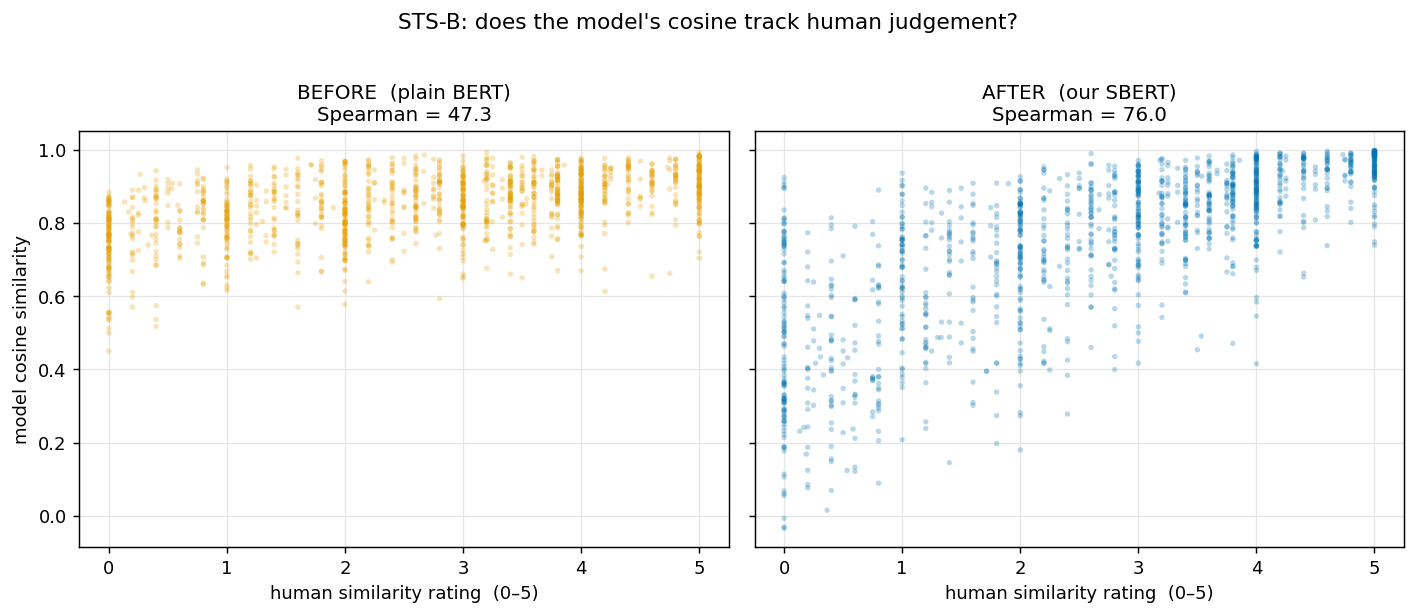

In [7]:
from IPython.display import Image
Image("assets/sts_scatter.png")

Before (left), the cloud is a shapeless blob squeezed into the top — every pair looks
similar, so cosine barely rises with the human score (nearly flat = low Spearman). After
(right), it stretches into a clear upward diagonal: the model now *ranks* pairs the way people
do. That diagonal **is** the Spearman number.

The paper reports an **average over seven** STS benchmarks, not just STS-B. Here's our
reproduction on all seven — plain BERT averages ~53, our fine-tuned model ~73, against the
paper's **74.89**:

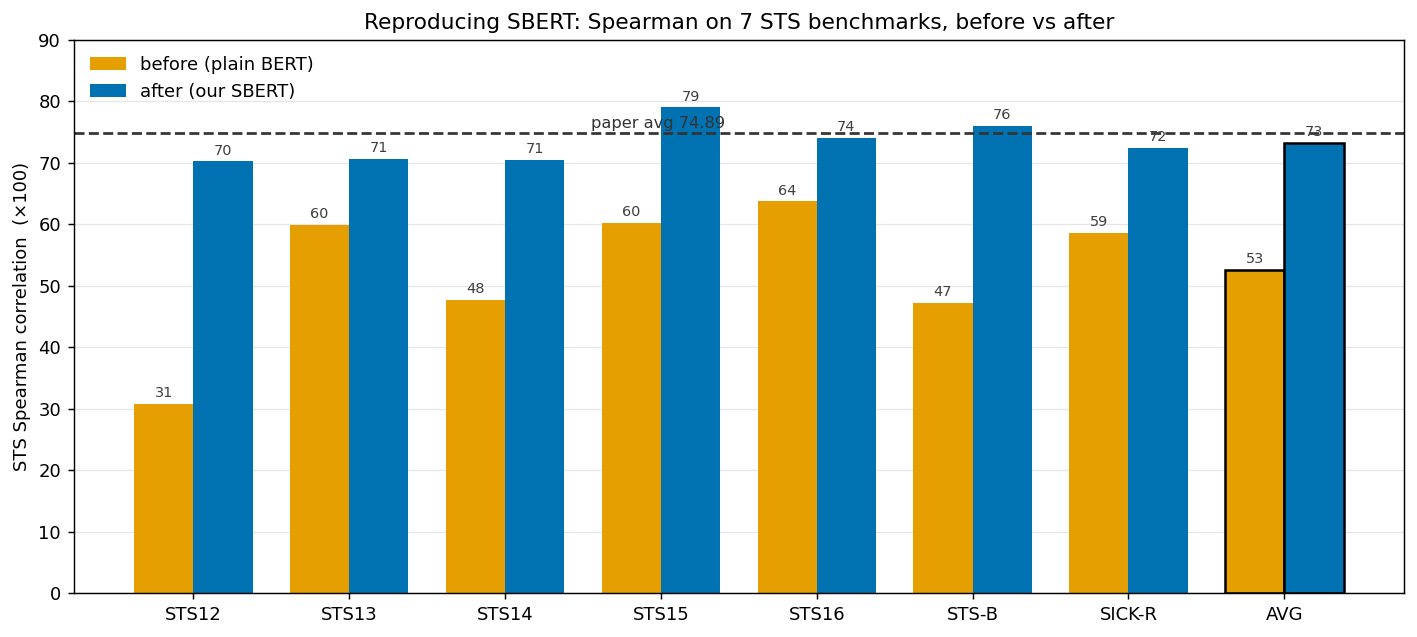

In [8]:
Image("assets/sts_bar.png")

Every single task jumps, and the **average climbs 52.6 → 73.3**, landing within ~1.6
points of the paper's 74.89 (we used a larger batch so it would finish in ~13 minutes; the
paper used batch 16). A clean reproduction of the headline result — trained on NLI, measured on
STS the model never saw.

## 15. Seeing the geometry reorganize

One last view, the most direct. Take nine sentences in **three meaning-groups** (refunds,
weather, cooking) and draw the full grid of pairwise cosine similarities — once for plain BERT,
once for our fine-tuned model.

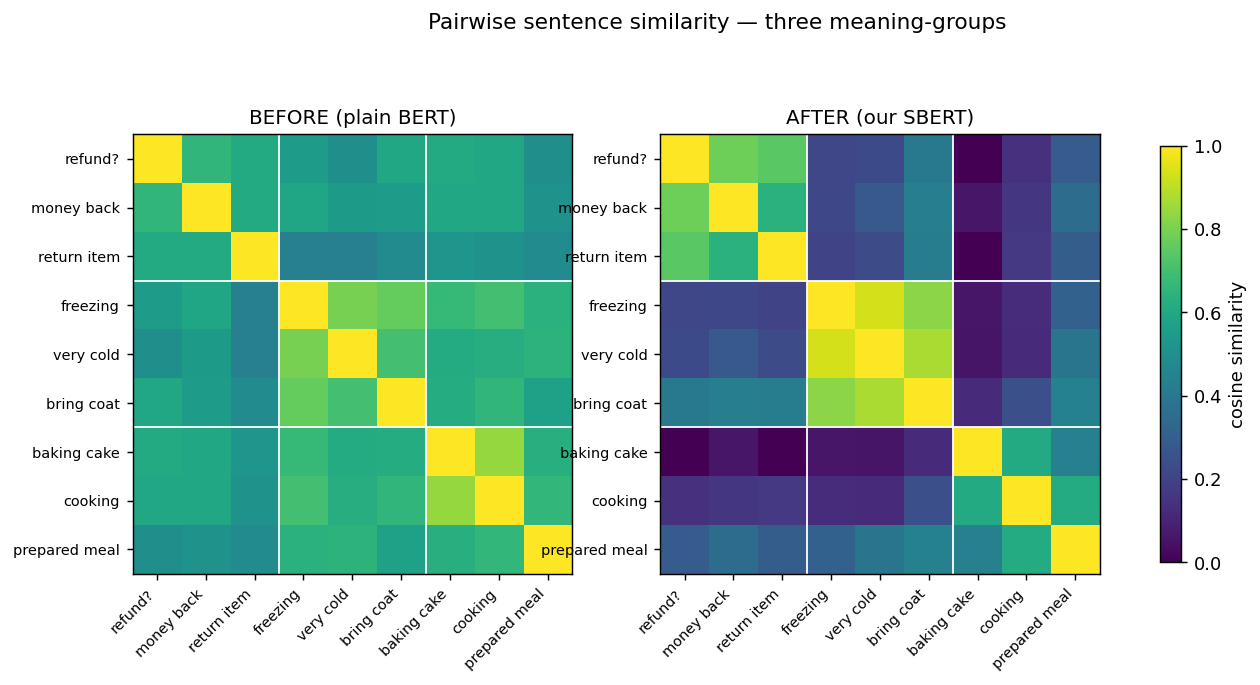

In [9]:
Image("assets/sts_heatmap.png")

Before (left), the grid is bright almost everywhere — plain BERT thinks every sentence is
fairly similar to every other (the anisotropic cone again), and the three groups barely
separate. After (right), **three crisp blocks** appear on the diagonal and the off-block regions
go dark: the model now places sentences by *meaning*. This block structure is exactly what makes
semantic search and RAG work.

## 16. Recap & references

| | plain BERT | SBERT (fine-tuned) |
|---|---|---|
| how you get a sentence vector | mean-pool the token vectors | **the same** mean pool |
| the code at inference | `embed_sentence` | **identical** |
| the weights inside | from masked-word training | **moved** by NLI training |
| STS-B Spearman | ~47 | **~76** |
| 7-task STS average | 52.6 | **73.3** (paper 74.89) |

You climbed the full ladder — **characters → words → words-in-context → sentences** — and at
every rung the same idea held: *train a model to predict or contrast, and useful vectors fall
out where geometry encodes meaning.* Here we closed the loop, not just *using* a sentence model
but **reproducing a published result** and measuring it against the authors' own benchmarks —
trained on NLI, scored on STS, only the weights moved.

**References**
- Reimers & Gurevych (2019), *Sentence-BERT: Sentence Embeddings using Siamese BERT-Networks*,
  EMNLP. [arXiv:1908.10084](https://arxiv.org/abs/1908.10084) — the paper reproduced here: the
  **siamese** setup, the **classification** objective over `[u; v; |u−v|]`, trained on
  **SNLI + MultiNLI**, evaluated on **STS**. Their ablation finds **mean pooling** beats the
  `[CLS]` vector — which is why we mean-pool throughout.
- `sentence-transformers` library & the `all-MiniLM-L6-v2` model card, HuggingFace — the
  reference implementation and the ready-made model used in Part I; trained with a contrastive
  in-batch-negatives objective over ~1.17B pairs.
- Ethayarajh (2019), *How Contextual are Contextualized Word Representations?*,
  [arXiv:1909.00512](https://arxiv.org/abs/1909.00512) — documents the **anisotropy** ("narrow
  cone") that makes plain-BERT cosine unreliable.